Install Dependencies

In [1]:
!pip install transformers datasets scikit-learn matplotlib seaborn pandas numpy torch -q
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


Load the LIAR Dataset

In [23]:
# Load dataset from HuggingFace Hub
from datasets import load_dataset
dataset = load_dataset("chengxuphd/liar2")
print(dataset)
print(dataset['train'].features)

print(f"\n📊 Dataset splits:")
print(f"  Train: {len(dataset['train'])} samples")
print(f"  Validation: {len(dataset['validation'])} samples")
print(f"  Test: {len(dataset['test'])} samples")

# Convert to pandas for EDA
train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print("\n✅ Dataset loaded!")
train_df.head()

DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 18369
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2297
    })
    test: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2296
    })
})
{'id': Value('int64'), 'label': Valu

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification
0,13847,5,"90 percent of Americans ""support universal bac...","October 2, 2017",government regulation;polls and public opinion...,chris abele,"Chris Abele is Milwaukee County Executive, a p...",wisconsin,1,4,5,3,5,2,a tweet,"""Universal"" is the term for background checks ..."
1,13411,1,Last year was one of the deadliest years ever ...,"May 19, 2017",after the fact;congress;criminal justice;histo...,thom tillis,Thom Tillis is a Republican who serves as U.S....,north carolina,0,2,7,3,2,0,a press release supporting the Back The Blue A...,"Sen. Thom Tillis, a North Carolina Republican,..."
2,10882,0,"Bernie Sanders's plan is ""to raise your taxes ...","October 28, 2015",taxes,chris christie,"Chris Christie announced June 6, 2023 that he ...",national,21,20,27,11,17,8,"Boulder, Colo","Christie said that Sanders’s plan is ""to raise..."
3,20697,4,Voter ID is supported by an overwhelming major...,"December 8, 2021",voter id laws,lee zeldin,Lee Zeldin is a Republican representing New Yo...,new york,1,2,0,0,0,0,a Tweet,Zeldin claimed voter identification requiremen...
4,6095,2,"Says Barack Obama ""robbed Medicare (of) $716 b...","August 12, 2012",federal budget;history;medicare;retirement,mitt romney,Mitt Romney is a U.S. senator from Utah. He ra...,national,31,33,58,35,32,19,"an interview on ""60 Minutes""","Romney said, ""There's only one president that ..."


Understand the Data

In [17]:
# Column names and types
print("Columns:", train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)
print("\nSample statement:")
print(train_df['statement'].iloc[0])
print("\nLabel:", train_df['label'].iloc[0])

Columns: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification', 'label_name', 'binary_id', 'binary_label']

Data types:
id                       int64
label                    int64
statement               object
date                    object
subject                 object
speaker                 object
speaker_description     object
state_info              object
true_counts              int64
mostly_true_counts       int64
half_true_counts         int64
mostly_false_counts      int64
false_counts             int64
pants_on_fire_counts     int64
context                 object
justification           object
label_name              object
binary_id                int64
binary_label            object
dtype: object

Sample statement:
90 percent of Americans "support universal background checks" for gun

In [18]:
# Label mapping — LIAR uses integers 0-5
label_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

# Map integer labels to string names for readability
train_df['label_name'] = train_df['label'].map(lambda x: label_names[x])
val_df['label_name']   = val_df['label'].map(lambda x: label_names[x])
test_df['label_name']  = test_df['label'].map(lambda x: label_names[x])

print("Label distribution in training set:")
print(train_df['label_name'].value_counts())

Label distribution in training set:
label_name
false          5284
half-true      2967
barely-true    2882
mostly-true    2743
pants-fire     2425
true           2068
Name: count, dtype: int64


Exploratory Data Analysis

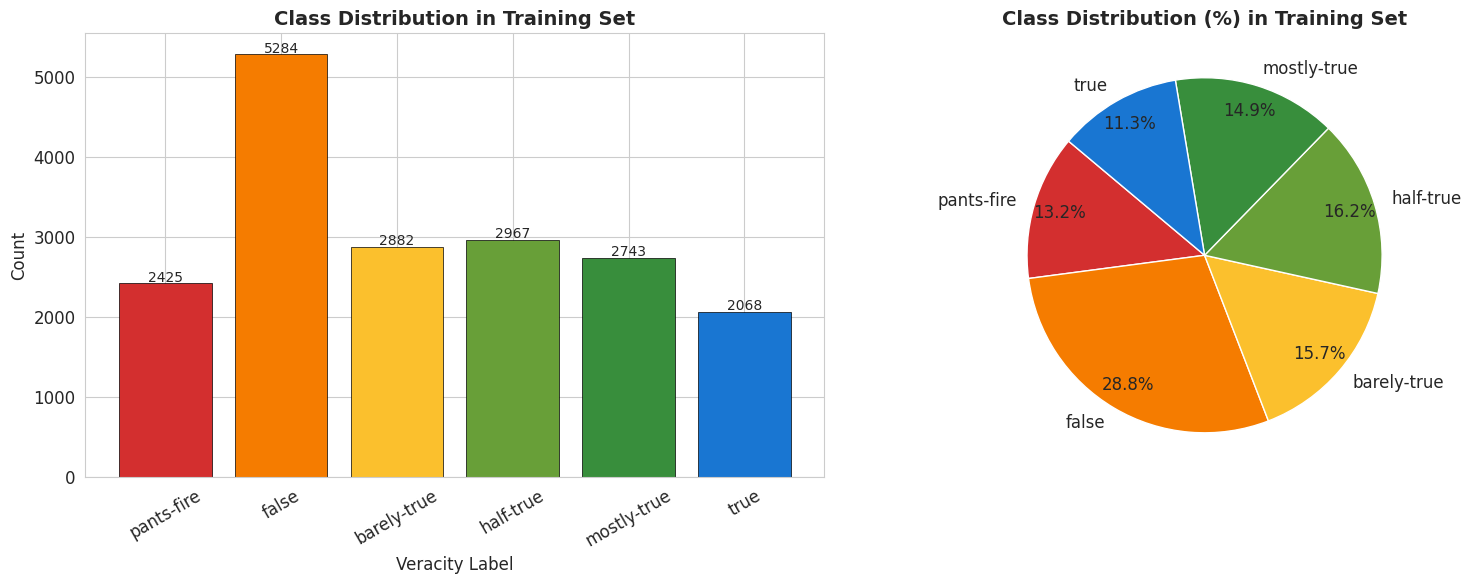


📌 Observation: The dataset is roughly balanced across 6 classes — this is important for training.


In [19]:
# ---- Plot 1: Class Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#d32f2f', '#f57c00', '#fbc02d', '#689f38', '#388e3c', '#1976d2']

# Bar chart
label_counts = train_df['label_name'].value_counts().reindex(label_names)
axes[0].bar(label_names, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Veracity Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(label_counts.values, labels=label_names, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.85)
axes[1].set_title('Class Distribution (%) in Training Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: The dataset is roughly balanced across 6 classes — this is important for training.")

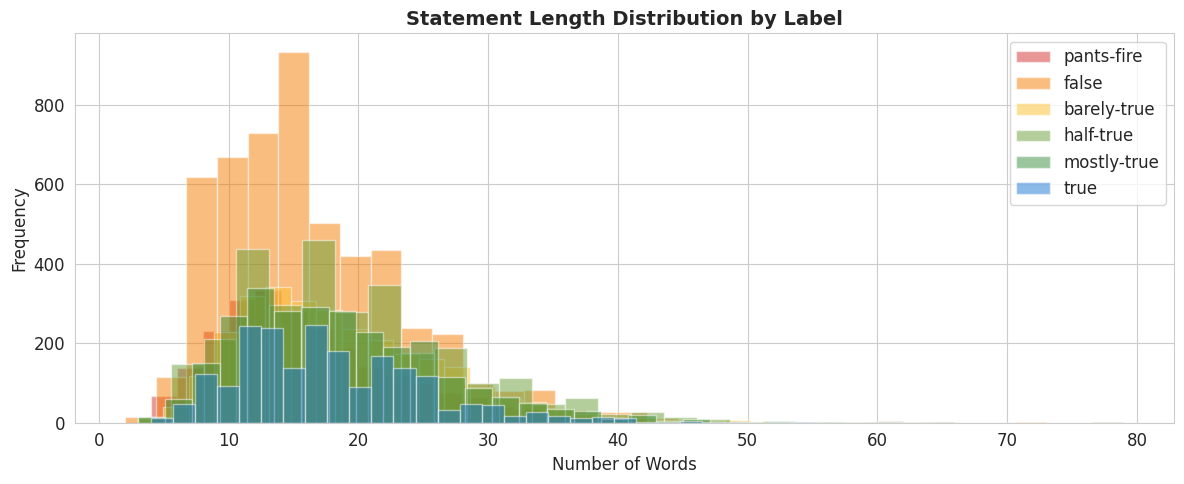


📌 Average statement length: 17.7 words
📌 Max statement length: 79 words
📌 Min statement length: 2 words


In [20]:
# ---- Plot 2: Statement Length Distribution ----
train_df['statement_length'] = train_df['statement'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(12, 5))
for i, label in enumerate(label_names):
    subset = train_df[train_df['label_name'] == label]['statement_length']
    ax.hist(subset, bins=30, alpha=0.5, label=label, color=colors[i])

ax.set_title('Statement Length Distribution by Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Average statement length: {train_df['statement_length'].mean():.1f} words")
print(f"📌 Max statement length: {train_df['statement_length'].max()} words")
print(f"📌 Min statement length: {train_df['statement_length'].min()} words")

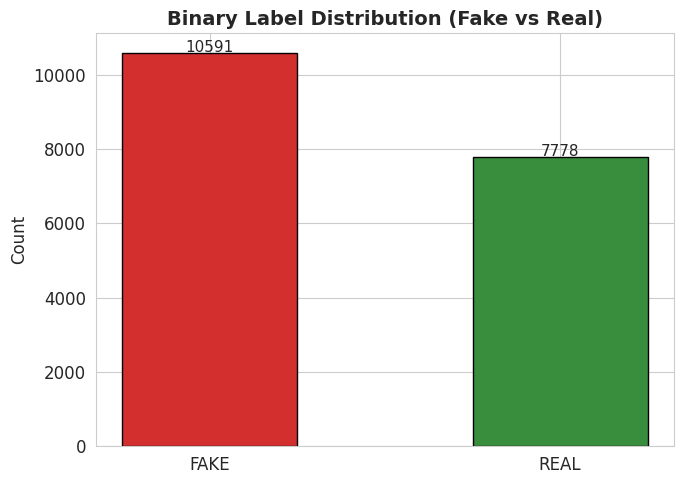


📌 Note: We will train on BOTH 6-class and binary versions and compare.


In [21]:
# ---- Plot 3: Binary grouping (Fake vs Real) for simplified analysis ----
# Group: pants-fire + false + barely-true = FAKE
#        half-true + mostly-true + true    = REAL

fake_labels = ['pants-fire', 'false', 'barely-true']
real_labels = ['half-true', 'mostly-true', 'true']

train_df['binary_label'] = train_df['label_name'].apply(
    lambda x: 'FAKE' if x in fake_labels else 'REAL'
)
val_df['binary_label'] = val_df['label_name'].apply(
    lambda x: 'FAKE' if x in fake_labels else 'REAL'
)
test_df['binary_label'] = test_df['label_name'].apply(
    lambda x: 'FAKE' if x in fake_labels else 'REAL'
)

binary_counts = train_df['binary_label'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(binary_counts.index, binary_counts.values,
       color=['#d32f2f', '#388e3c'], edgecolor='black', width=0.5)
ax.set_title('Binary Label Distribution (Fake vs Real)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Note: We will train on BOTH 6-class and binary versions and compare.")

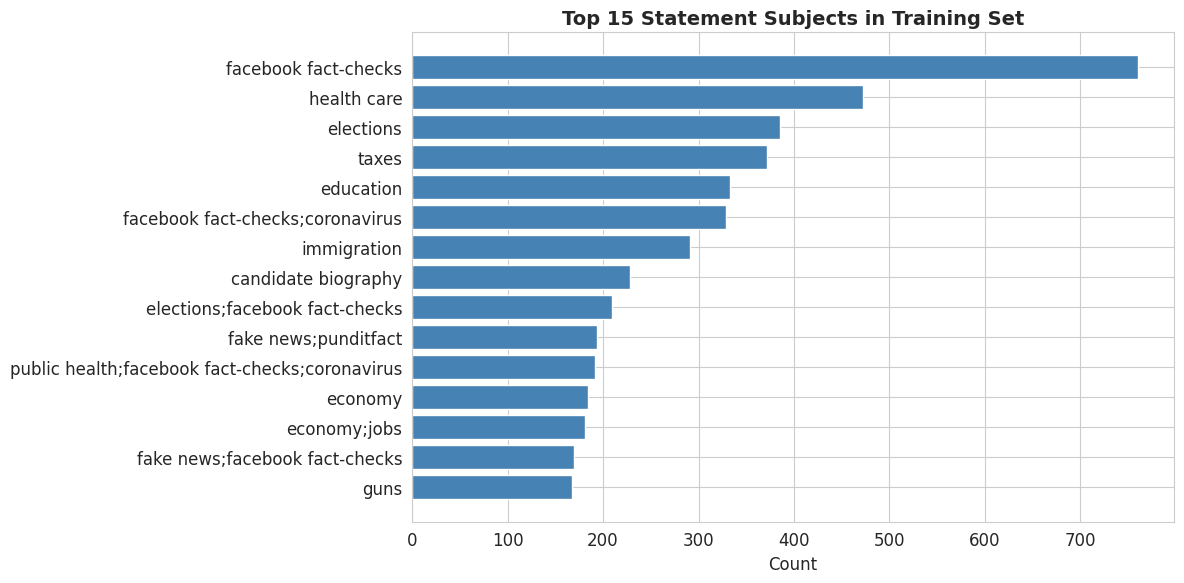

In [22]:
# ---- Plot 4: Speaker subject distribution ----
top_subjects = train_df['subject'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_subjects.index[::-1], top_subjects.values[::-1], color='steelblue')
ax.set_title('Top 15 Statement Subjects in Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Text Preprocessing & Tokenizer Preview

In [12]:
from transformers import BertTokenizer

# Load BERT tokenizer
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Test tokenization
sample = train_df['statement'].iloc[0]
print(f"\nSample statement:\n{sample}")

tokens = tokenizer(sample, truncation=True, padding='max_length',
                   max_length=128, return_tensors='pt')

print(f"\nToken IDs shape: {tokens['input_ids'].shape}")
print(f"Decoded back: {tokenizer.decode(tokens['input_ids'][0], skip_special_tokens=True)}")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Sample statement:
90 percent of Americans "support universal background checks" for gun purchases.

Token IDs shape: torch.Size([1, 128])
Decoded back: 90 percent of americans " support universal background checks " for gun purchases.


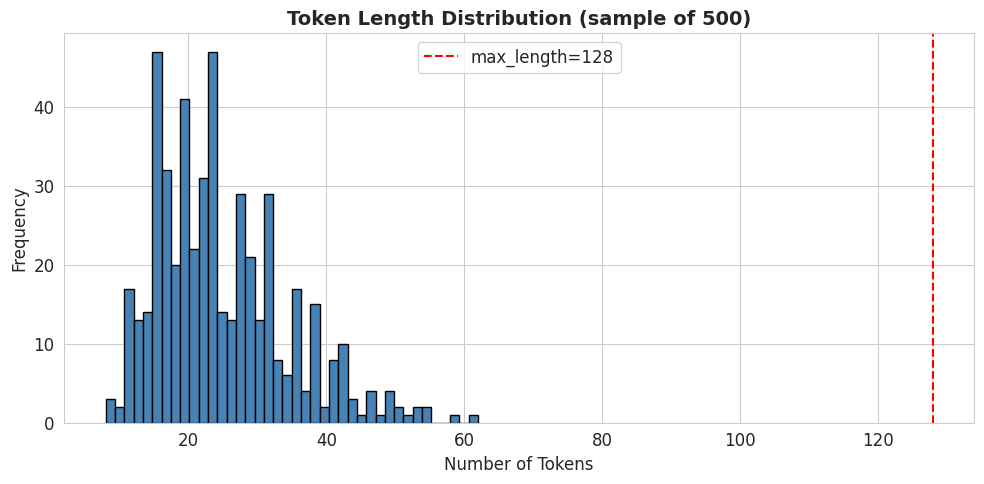


📌 100.0% of statements fit within 128 tokens.
📌 We will use max_length=128 for training — safe and memory-efficient on Colab.


In [13]:
# Check token length distribution to choose max_length for training
lengths = [len(tokenizer.encode(s, truncation=False)) for s in train_df['statement'].sample(500)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='black')
ax.axvline(x=128, color='red', linestyle='--', label='max_length=128')
ax.set_title('Token Length Distribution (sample of 500)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 {sum(l <= 128 for l in lengths)/len(lengths)*100:.1f}% of statements fit within 128 tokens.")
print("📌 We will use max_length=128 for training — safe and memory-efficient on Colab.")

In [14]:
# Save processed dataframes for Week 2
train_df.to_csv('train_processed.csv', index=False)
val_df.to_csv('val_processed.csv', index=False)
test_df.to_csv('test_processed.csv', index=False)

print("✅ Week 1 Complete! Saved:")
print("  - train_processed.csv")
print("  - val_processed.csv")
print("  - test_processed.csv")
print("\n📋 Summary:")
print(f"  Total training samples: {len(train_df)}")
print(f"  6 veracity classes: {label_names}")
print(f"  Binary split: {train_df['binary_label'].value_counts().to_dict()}")
print(f"  Recommended max_length: 128 tokens")
print("\n➡️  Proceed to Week2_BERT_Finetuning.ipynb")

✅ Week 1 Complete! Saved:
  - train_processed.csv
  - val_processed.csv
  - test_processed.csv

📋 Summary:
  Total training samples: 18369
  6 veracity classes: ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
  Binary split: {'FAKE': 10591, 'REAL': 7778}
  Recommended max_length: 128 tokens

➡️  Proceed to Week2_BERT_Finetuning.ipynb


In [15]:
print(dataset['train'].features)
print(dataset['train'][0])

{'id': Value('int64'), 'label': Value('int64'), 'statement': Value('string'), 'date': Value('string'), 'subject': Value('string'), 'speaker': Value('string'), 'speaker_description': Value('string'), 'state_info': Value('string'), 'true_counts': Value('int64'), 'mostly_true_counts': Value('int64'), 'half_true_counts': Value('int64'), 'mostly_false_counts': Value('int64'), 'false_counts': Value('int64'), 'pants_on_fire_counts': Value('int64'), 'context': Value('string'), 'justification': Value('string')}
{'id': 13847, 'label': 5, 'statement': '90 percent of Americans "support universal background checks" for gun purchases.', 'date': 'October 2, 2017', 'subject': 'government regulation;polls and public opinion;guns', 'speaker': 'chris abele', 'speaker_description': 'Chris Abele is Milwaukee County Executive, a position he won in an April 2011 special election to finish out the final year of the term of Scott Walker, who was elected governor in November 2010. The election was the first att